In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data/gold.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [3]:
df.shape

(559, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 559 entries, 2024-05-21 to 2026-05-01
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       559 non-null    float64
 1   open        559 non-null    float64
 2   high        559 non-null    float64
 3   low         559 non-null    float64
 4   vol         0 non-null      float64
 5   change_pct  559 non-null    float64
dtypes: float64(6)
memory usage: 30.6 KB


In [5]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2024-05-21,3638.20,3637.19,3649.74,3609.97,NaN,0.00
2024-05-22,3584.23,3638.35,3645.13,3573.15,NaN,-1.48
2024-05-23,3535.19,3583.54,3591.35,3526.32,NaN,-1.37
2024-05-24,3538.40,3534.50,3557.73,3526.20,NaN,0.09
2024-05-27,3567.25,3542.51,3580.28,3527.54,NaN,0.82


In [6]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2026-04-27,7928.40,7916.34,8010.18,7888.46,NaN,0.11
2026-04-28,7805.98,7930.61,7942.07,7739.30,NaN,-1.54
2026-04-29,7775.14,7813.37,7829.80,7676.44,NaN,-0.39
2026-04-30,7961.02,7776.58,8006.40,7740.62,NaN,2.39
2026-05-01,7977.18,7958.50,8018.34,7849.06,NaN,0.20


In [7]:
#print null count
print(df.isnull().sum())

price           0
open            0
high            0
low             0
vol           559
change_pct      0
dtype: int64


In [8]:
#drop vol column
df.drop(columns="vol", inplace=True)

In [9]:
#Computing daily % return 
df['return'] = df['price'].pct_change()

In [10]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [11]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [12]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [13]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [14]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [15]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [16]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [17]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [18]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [19]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 539 entries, 2024-06-18 to 2026-05-01
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           539 non-null    float64
 1   high           539 non-null    float64
 2   low            539 non-null    float64
 3   change_pct     539 non-null    float64
 4   return         539 non-null    float64
 5   return_lag1    539 non-null    float64
 6   return_lag2    539 non-null    float64
 7   volatility_20  539 non-null    float64
 8   dist_to_ma5    539 non-null    float64
 9   dist_to_ma20   539 non-null    float64
 10  macd           539 non-null    float64
 11  macd_signal    539 non-null    float64
 12  macd_hist      539 non-null    float64
 13  bb_pb          539 non-null    float64
 14  bb_bandwidth   539 non-null    float64
 15  rsi            539 non-null    float64
 16  label          539 non-null    int64  
dtypes: float64(16), int64(1)
memory usage: 75.8 KB

In [20]:
df.head()

,open,high,low,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,
2024-06-18,3561.87,3578.15,3538.38,0.34,0.003374,-0.004951,0.012894,0.011967,0.003327,0.002793,-14.333791,-17.299148,2.965357,0.583773,0.033342,50.854630,0
2024-06-19,3572.48,3581.44,3565.70,0.05,0.000490,0.003374,-0.004951,0.011506,0.002984,0.003437,-12.446623,-16.328643,3.882020,0.604247,0.032971,51.483612,1
2024-06-20,3573.39,3627.85,3570.97,1.33,0.013323,0.000490,0.003374,0.011411,0.011283,0.015583,-7.028282,-14.468571,7.440289,0.940276,0.035393,59.523863,0
2024-06-21,3620.83,3633.32,3554.10,-1.65,-0.016462,0.013323,0.000490,0.012081,-0.004478,-0.001458,-7.458262,-13.066509,5.608247,0.457952,0.034680,50.209685,1
2024-06-24,3558.38,3641.91,3557.33,1.68,0.016811,-0.016462,0.013323,0.012521,0.008782,0.014560,-2.934192,-11.040046,8.105853,0.890691,0.037267,56.453704,0


In [21]:
df.tail()

,open,high,low,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,
2026-04-27,7916.34,8010.18,7888.46,0.11,0.001105,-0.006206,0.003525,0.018746,-0.000590,-0.014287,-24.923013,-8.347662,-16.575350,0.292825,0.068962,42.310283,0
2026-04-28,7930.61,7942.07,7739.30,-1.54,-0.015441,0.001105,-0.006206,0.018892,-0.013506,-0.027878,-36.227643,-13.923659,-22.303985,0.122246,0.073800,42.749577,0
2026-04-29,7813.37,7829.80,7676.44,-0.39,-0.003951,-0.015441,0.001105,0.018738,-0.013264,-0.029470,-47.131868,-20.565300,-26.566568,0.121157,0.077790,33.129252,1
2026-04-30,7776.58,8006.40,7740.62,2.39,0.023907,-0.003951,-0.015441,0.016713,0.010533,-0.002937,-40.309914,-24.514223,-15.795691,0.444776,0.053188,41.806431,0
2026-05-01,7958.50,8018.34,7849.06,0.20,0.002030,0.023907,-0.003951,0.012617,0.011108,-0.000310,-33.216590,-26.254697,-6.961893,0.494055,0.052173,46.312432,0


In [23]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

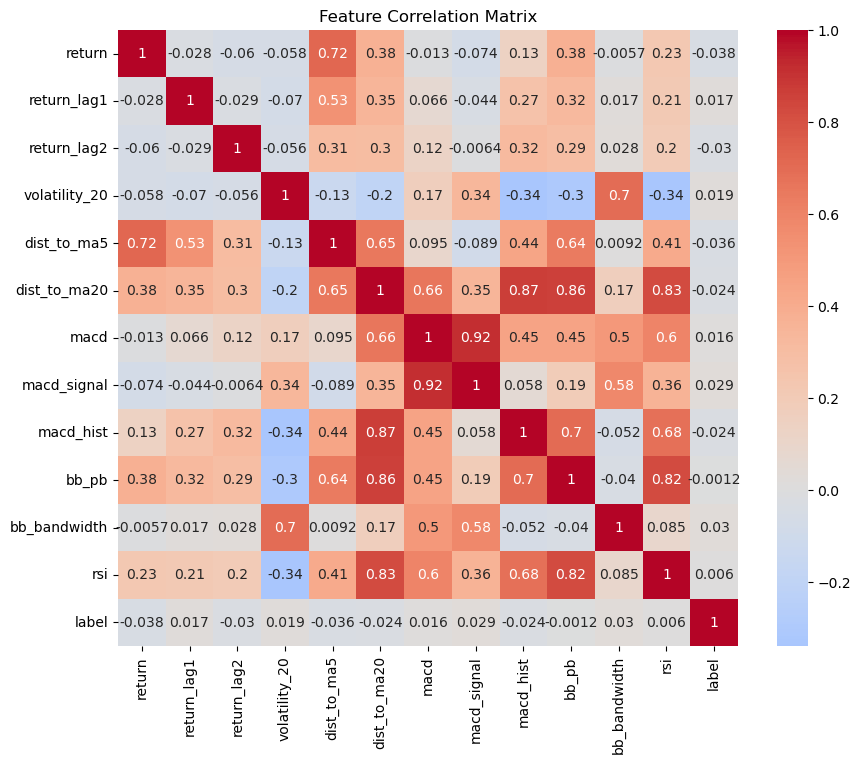

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [25]:
#Dropping multicolinearity features
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

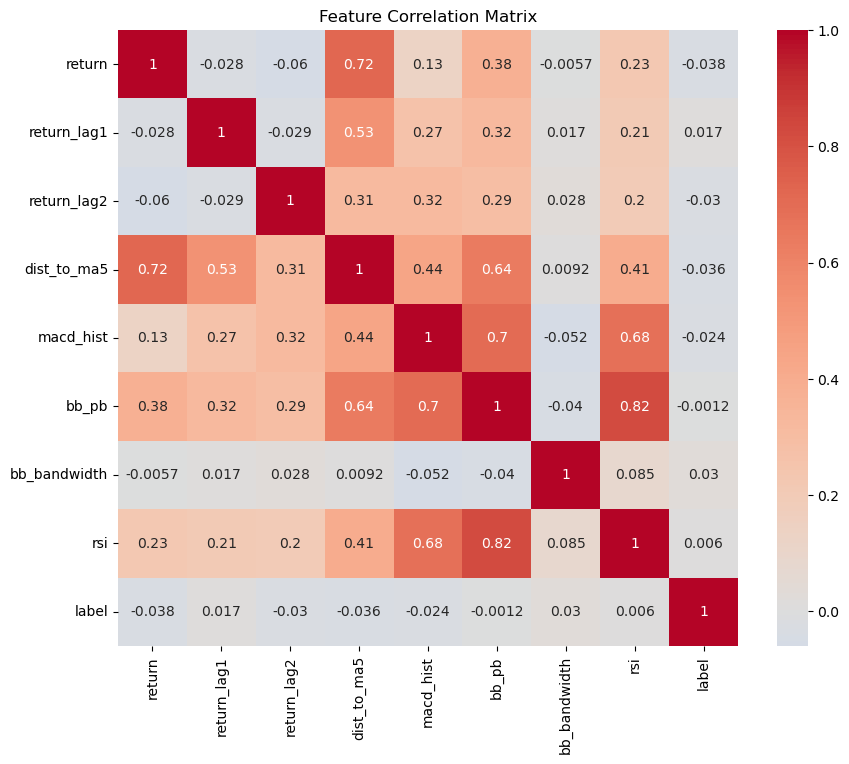

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [27]:
asset_name = "Gold Index" 
sns.set_theme(style="darkgrid", palette="muted")

# We calculate Cumulative Return to visualize the "price" growth
cum_return = (1 + df['return']).cumprod()

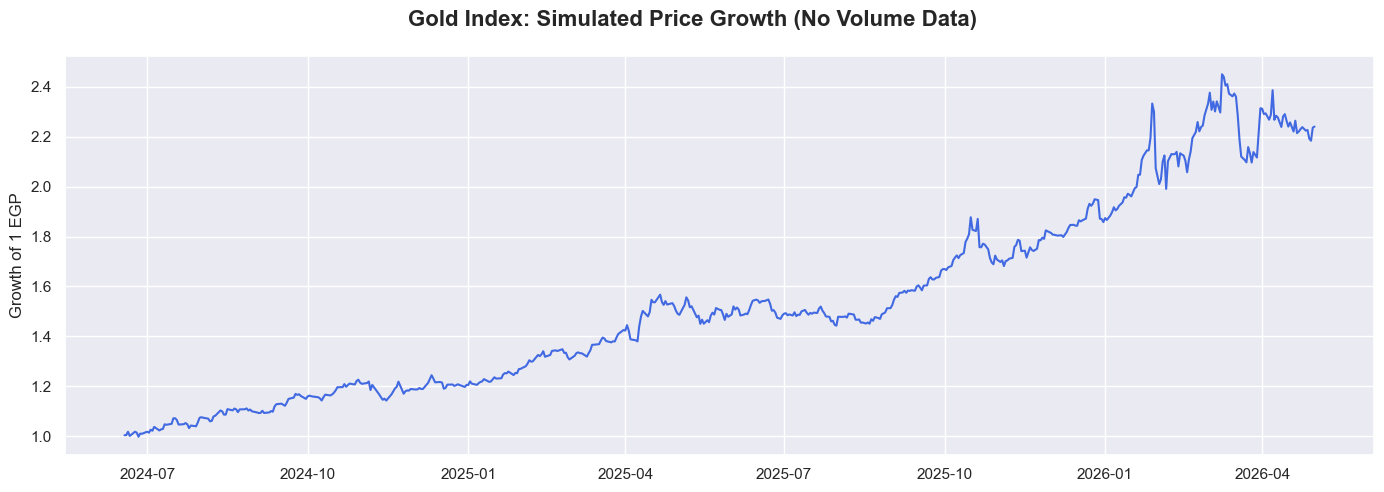

In [28]:
# ========================================================
# PLOT 1 - Macro Trend & Volume
# ========================================================
if 'vol' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f"{asset_name}: Simulated Price Growth & Volume", fontsize=16, fontweight='bold')
    
    # Top Panel: Simulated Price (Cumulative Return)
    axes[0].plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    axes[0].set_ylabel("Growth of 1 EGP")
    axes[0].set_title("Cumulative Returns Over Time")
    
    # Bottom Panel: Volume (FIXED: using fill_between instead of bar)
    axes[1].fill_between(df.index, df['vol'], color='slategray', alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].margins(x=0) # Removes white space on the edges
    
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{asset_name}: Simulated Price Growth (No Volume Data)", fontsize=16, fontweight='bold')
    ax.plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    ax.set_ylabel("Growth of 1 EGP")

plt.tight_layout()
plt.show()

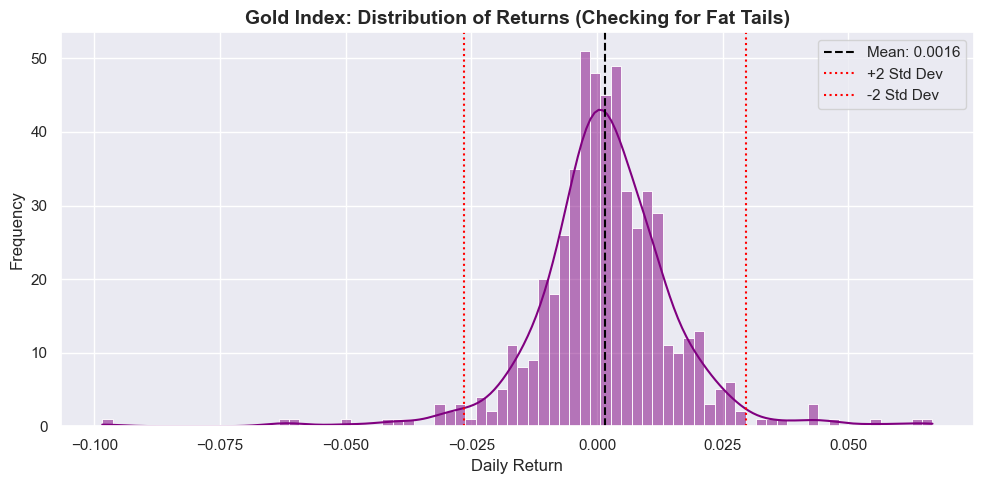

In [29]:
# ========================================================
# PLOT 2 - Distribution of Returns (Fat Tails)
# ========================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['return'], kde=True, bins=80, color='purple')
plt.title(f"{asset_name}: Distribution of Returns (Checking for Fat Tails)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Add statistical lines
mean_ret = df['return'].mean()
std_ret = df['return'].std()
plt.axvline(mean_ret, color='black', linestyle='--', label=f'Mean: {mean_ret:.4f}')
plt.axvline(mean_ret + (2*std_ret), color='red', linestyle=':', label='+2 Std Dev')
plt.axvline(mean_ret - (2*std_ret), color='red', linestyle=':', label='-2 Std Dev')

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_28144\3776502680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


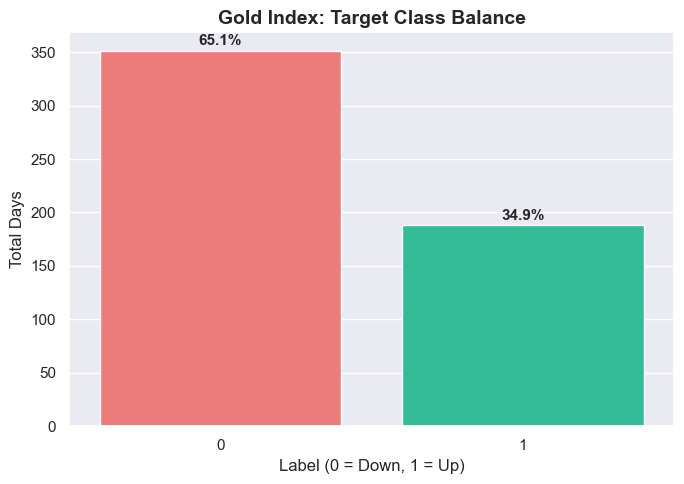

In [30]:
# ========================================================
# PLOT 3 - Target Class Balance
# ========================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)")
plt.ylabel("Total Days")

# Calculate and add percentages to the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)
    
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_28144\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28144\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28144\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

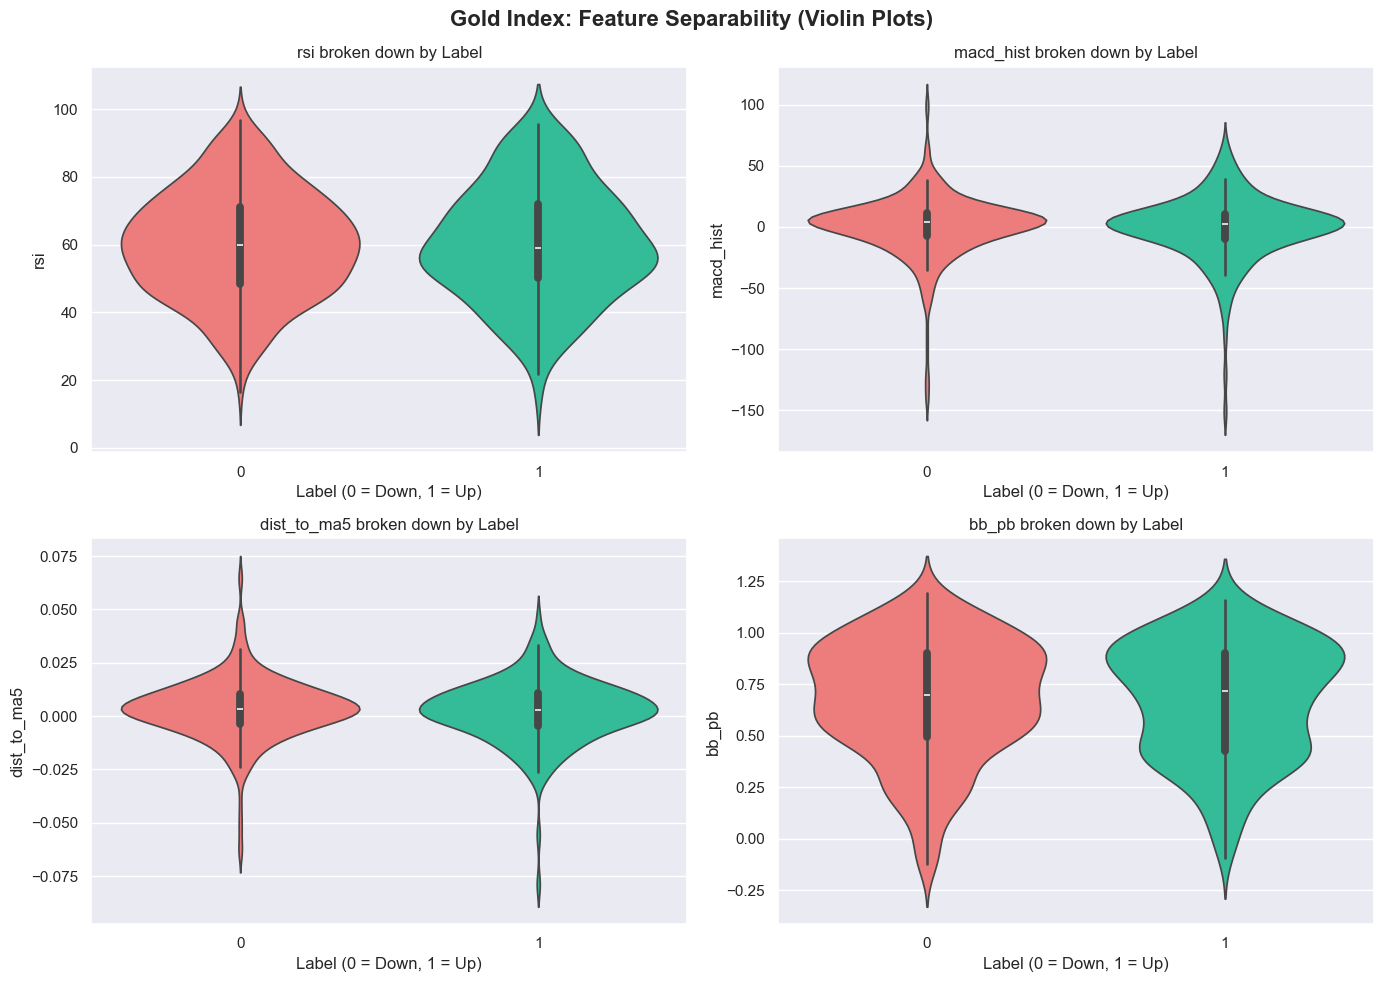

In [31]:
# ========================================================
# PLOT 4 - Feature Predictability (Violin Plots)
# ========================================================
# Selecting the 4 best ML features to plot
features = ['rsi', 'macd_hist', 'dist_to_ma5', 'bb_pb']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{asset_name}: Feature Separability (Violin Plots)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

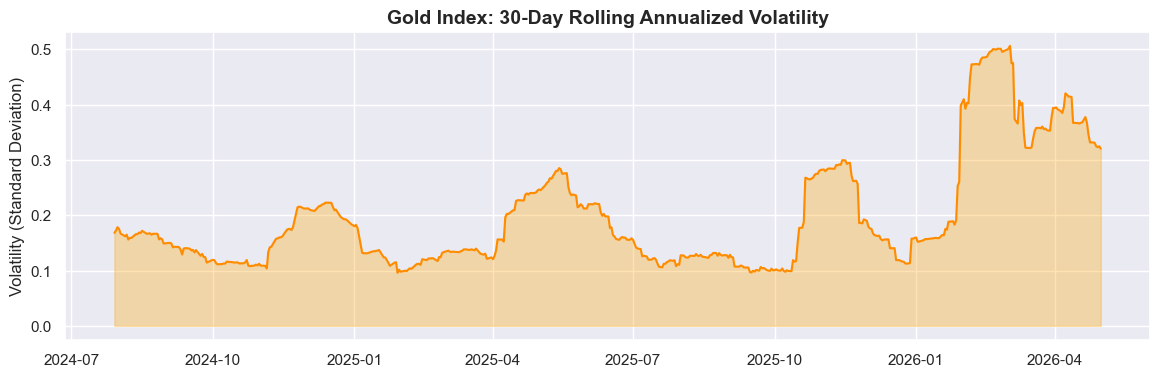

In [32]:
# CELL 7: Rolling Volatility (30-day)
df['rolling_volatility'] = df['return'].rolling(window=30).std() * np.sqrt(252) # Annualized

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['rolling_volatility'], color='darkorange', linewidth=1.5)
plt.title(f"{asset_name}: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (Standard Deviation)")
plt.fill_between(df.index, df['rolling_volatility'], alpha=0.3, color='orange')
plt.show()

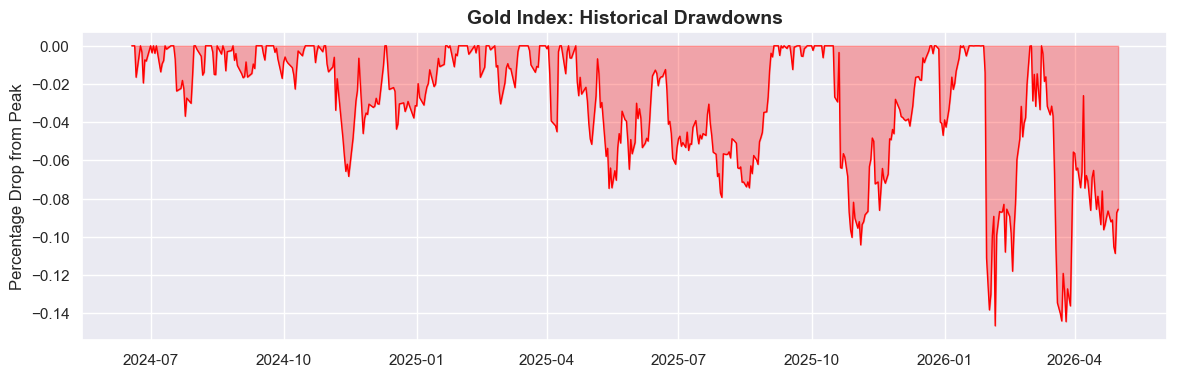

In [33]:
# CELL 8: Drawdown Chart
running_max = cum_return.cummax()
drawdown = (cum_return - running_max) / running_max

plt.figure(figsize=(14, 4))
plt.plot(df.index, drawdown, color='red', linewidth=1)
plt.fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
plt.title(f"{asset_name}: Historical Drawdowns", fontsize=14, fontweight='bold')
plt.ylabel("Percentage Drop from Peak")
plt.show()

In [34]:
df.to_csv('final_data/final_gold.csv')